1. IMPORTS

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA





2. LOADING AND CLEANING DATA

In [2]:
df = pd.read_csv("C:\\Users\\HP-PC\\Downloads\\log.csv")
df.shapedf=df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))


df = df[df['DPOR'] >= 0]     
df = df[df['CNLS'] >= 0]     
df = df[df['RHOB'] > 0]     

print("Data shape after cleaning:", df.shape)


Data shape after cleaning: (8682, 14)


C:\Users\HP-PC\AppData\Local\Temp\ipykernel_24400\3886431495.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.shapedf=df.drop_duplicates()


3. FEATURE SELECTION

In [3]:
X = df[['Depth','GR','RILD','DPOR','RHOB','SP']]
#depth , GR= gamma ray, RILD = Induction log (resistivity),DPOR =Density Porosity , RHOB= Bulk Density , SP= Sponatneous Potential

import numpy as np

gr_low   = df['GR'].quantile(0.40)     # sand tendency
gr_high  = df['GR'].quantile(0.70)     # shale tendency

res_high = df['RILD'].quantile(0.65)   # high resistivity
res_low  = df['RILD'].quantile(0.35)   # low resistivity

por_high = df['DPOR'].quantile(0.60)   # good porosity
por_low  = df['DPOR'].quantile(0.30)   # poor porosity

den_low  = df['RHOB'].quantile(0.40)   # lighter rock (sand)
den_high = df['RHOB'].quantile(0.70)   # denser rock (shale)

sp_str   = df['SP'].abs().quantile(0.70)  # strong SP deflection


df['sand_score'] = 0


df.loc[df['GR']   < gr_low,   'sand_score'] += 1
df.loc[df['RILD'] > res_high,'sand_score'] += 1
df.loc[df['DPOR'] > por_high,'sand_score'] += 1
df.loc[df['RHOB'] < den_low, 'sand_score'] += 1
df.loc[df['SP'].abs() > sp_str, 'sand_score'] += 1



df.loc[df['GR']   > gr_high,  'sand_score'] -= 1
df.loc[df['RILD'] < res_low, 'sand_score'] -= 1
df.loc[df['DPOR'] < por_low, 'sand_score'] -= 1
df.loc[df['RHOB'] > den_high,'sand_score'] -= 1
df.loc[(df['SP'].abs() < sp_str) & (df['GR'] > gr_high), 'sand_score'] -= 1


df['Facies'] = np.where(df['sand_score'] >= 2,
                        'Sandstone',
                        'Shale')


print(df['Facies'].value_counts())


Facies
Shale        5887
Sandstone    2795
Name: count, dtype: int64


4. ENCODING LABELS

In [4]:
X = df[['Depth','GR', 'DPOR', 'RHOB', 'RILD', 'SP']]
y = df['Facies']
le = LabelEncoder()
y = le.fit_transform(y)
# Sandstone -> 0, Shale -> 1




5. TRAIN - TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.3,
    random_state=42,
    stratify=y   # keeps sandstone/shale ratio same
)
print("training samples:",len(X_train))
      


training samples: 2604


6. SCALING 

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled  = scaler.transform(X_test)        # apply same scaling to test



7. PCA(DIMENSIONALITY REDUCTION)

In [14]:
pca = PCA(n_components=0.98)   # keep 98% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)


print("Before PCA:", X_train.shape[1])
print("After PCA :", X_train_pca.shape[1])

Before PCA: 6
After PCA : 5


8. TRAINING MODEL

In [16]:
svm_model_pca = SVC(
    kernel='rbf',
    C=5,
    gamma='scale',
    class_weight='balanced'   # handles class imbalance
)

svm_model_pca.fit(X_train_pca, y_train)



SVC(C=5, class_weight='balanced')

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

print("Best parameters:", grid.best_params_)

svm_model = grid.best_estimator_



Best parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}


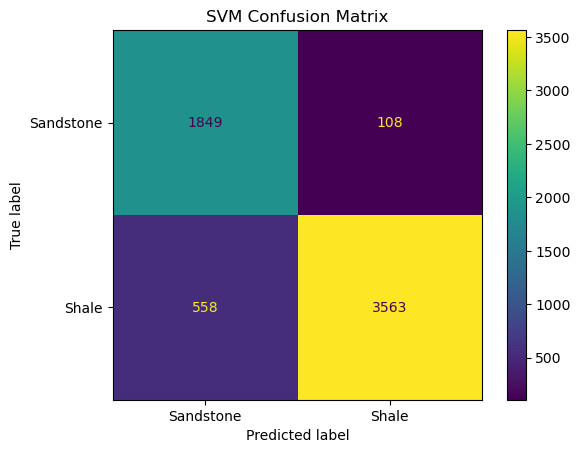

Accuracy: 0.8904244817374136

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85      1957
           1       0.97      0.86      0.91      4121

    accuracy                           0.89      6078
   macro avg       0.87      0.90      0.88      6078
weighted avg       0.91      0.89      0.89      6078


Confusion Matrix:
[[1849  108]
 [ 558 3563]]


In [18]:
y_pred = svm_model_pca.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Sandstone","Shale"])
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()



print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [19]:
import os
import joblib

folder_path = os.path.abspath("saved_models")


os.makedirs(folder_path, exist_ok=True)


svm_path = os.path.join(folder_path, "svm.pkl")
scaler_path = os.path.join(folder_path, "svm_scaler.pkl")
pca_path = os.path.join(folder_path, "svm_pca.pkl")


joblib.dump(svm_model, svm_path)
joblib.dump(scaler, scaler_path)
joblib.dump(pca, pca_path)

print("SVM saved successfully.")



SVM saved successfully.


In [12]:

df["Model"]='SVM'
df.to_csv('svm_output.csv', index=False)
